Milestone 2 – Data Integration & SQL-style EDA


“In Milestone 2, I’m shifting from exploratory plots to structured, SQL-style analysis. I’m treating the trip data as a fact table and using time-based dimensions like hour and weekday to aggregate demand and answer specific operational questions.”

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)


In [3]:
import glob

files_2014 = glob.glob("C:\\Users\\jeffr\\OneDrive\\Desktop\\motorq_hackathon_practice\\data\\raw\\uber_2014\\*.csv")

uber14 = pd.concat(
    (pd.read_csv(f) for f in files_2014),
    ignore_index=True
)

uber14.shape


(4534327, 4)

creating time dimensions

In [4]:
uber14["Date/Time"] = pd.to_datetime(uber14["Date/Time"])

uber14["hour"] = uber14["Date/Time"].dt.hour
uber14["day"] = uber14["Date/Time"].dt.day
uber14["weekday"] = uber14["Date/Time"].dt.weekday


In [5]:
uber14.head()

,Date/Time,Lat,Lon,Base,hour,day,weekday
0,2014-04-01 00:11:00,40.7690,-73.9549,B02512,0,1,1
1,2014-04-01 00:17:00,40.7267,-74.0345,B02512,0,1,1
2,2014-04-01 00:21:00,40.7316,-73.9873,B02512,0,1,1
3,2014-04-01 00:28:00,40.7588,-73.9776,B02512,0,1,1
4,2014-04-01 00:33:00,40.7594,-73.9722,B02512,0,1,1


STEP 2.1: Pickups per hour

In [6]:
pickups_by_hour = (
    uber14
    .groupby("hour")
    .size()
    .reset_index(name="pickup_count")
    .sort_values("hour")
)

pickups_by_hour


,hour,pickup_count
0,0,103836
1,1,67227
2,2,45865
3,3,48287
4,4,55230
5,5,83939
6,6,143213
7,7,193094
8,8,190504
9,9,159967


🔹 STEP 2.2: Pickups by weekday (THIS IS NEW)

In [7]:
pickups_by_weekday = (
    uber14
    .groupby("weekday")
    .size()
    .reset_index(name="pickup_count")
    .sort_values("weekday")
)

pickups_by_weekday


,weekday,pickup_count
0,0,541472
1,1,663789
2,2,696488
3,3,755145
4,4,741139
5,5,646114
6,6,490180


🔹 STEP 2.3: Hour × Weekday (IMPORTANT)


“At what hours on which days is demand highest?”

In [8]:
hour_weekday_demand = (
    uber14
    .groupby(["weekday", "hour"])
    .size()
    .reset_index(name="pickup_count")
)

hour_weekday_demand.head()


,weekday,hour,pickup_count
0,0,0,6436
1,0,1,3737
2,0,2,2938
3,0,3,6232
4,0,4,9640


🔹 STEP 2.4: One simple visualization (heatmap)

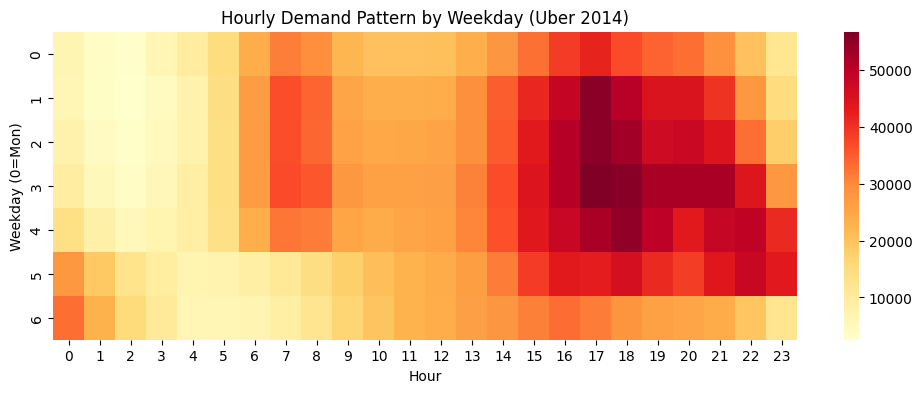

In [9]:
pivot_hw = hour_weekday_demand.pivot(
    index="weekday",
    columns="hour",
    values="pickup_count"
)

plt.figure(figsize=(12,4))
sns.heatmap(pivot_hw, cmap="YlOrRd")
plt.title("Hourly Demand Pattern by Weekday (Uber 2014)")
plt.xlabel("Hour")
plt.ylabel("Weekday (0=Mon)")
plt.show()


📌 Inference from Hour × Weekday Heatmap (Uber 2014)

The heatmap shows how pickup demand varies by hour of the day and day of the week.

A few clear patterns emerge:

Weekday evenings (Monday to Friday, around 4 PM – 7 PM) show the highest pickup demand, indicating strong evening commute and post-work travel behavior.

Morning hours on weekdays (around 7 AM – 9 AM) also show elevated demand, corresponding to typical commute times.

Weekends (Saturday and Sunday) display a different pattern, with demand starting later in the day and being more evenly spread across afternoon and evening hours, rather than sharp commute peaks.

Early morning hours (12 AM – 5 AM) consistently show low pickup activity across all days of the week.

Overall, this heatmap indicates that pickup demand is driven by the interaction of hour and weekday, not by hour alone. These patterns suggest that fleet operators should prioritize vehicle availability during weekday commute hours, especially in the evening, while adopting a more flexible strategy on weekends.

Step 3: Base-level Analysis

🔹 Step 3.1: Pickups per Base (SQL thinking)

In [10]:
pickups_by_base = (
    uber14
    .groupby("Base")
    .size()
    .reset_index(name="pickup_count")
    .sort_values("pickup_count", ascending=False)
)

pickups_by_base.head(10)


,Base,pickup_count
2,B02617,1458853
1,B02598,1393113
3,B02682,1212789
4,B02764,263899
0,B02512,205673


🔹 Step 3.2: Base × Hour (IMPORTANT)

In [11]:
base_hour_demand = (
    uber14
    .groupby(["Base", "hour"])
    .size()
    .reset_index(name="pickup_count")
)


In [12]:
base_hour_demand[
    base_hour_demand["hour"].between(16, 19)
].sort_values("pickup_count", ascending=False).head(10)

,Base,hour,pickup_count
65,B02617,17,107590
41,B02598,17,104759
66,B02617,18,104196
42,B02598,18,101050
64,B02617,16,99353
40,B02598,16,98426
67,B02617,19,95071
43,B02598,19,90587
89,B02682,17,88921
90,B02682,18,85053


inferences: “A small number of bases drive a disproportionate share of peak-hour demand, making them priority targets for resource allocation.”

📌 Inference from Base × Peak Hour Analysis (Uber 2014)

The base-level analysis during peak hours (4–7 PM) shows that pickup demand is highly concentrated among a small number of bases, particularly B02617 and B02598. These bases consistently rank at the top across multiple peak hours, indicating sustained high operational load rather than isolated spikes.

This suggests that fleet demand is not evenly distributed across all dispatch bases. From an operational perspective, ensuring sufficient vehicle availability and dispatch capacity at these high-performing bases during peak hours is critical to meeting demand and minimizing wait times.

In [13]:
uber14.isnull().sum()

Date/Time    0
Lat          0
Lon          0
Base         0
hour         0
day          0
weekday      0
dtype: int64

“Uber 2014 was mainly used for exploratory analysis and understanding demand patterns, so basic schema checks were sufficient. Uber 2015 is the modeling dataset, so that’s where we need strict time-series completeness, missing-hour handling, and careful feature engineering.”